# Print tsvs

In [6]:
import pandas as pd

pheno_fp = "/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/tsvs/P-1_W-B2_T-3581__phenotype_cp.tsv"
vac_fp = "/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/tsvs/P-1_W-B2_T-3581__cell_vacuole_table.tsv"
vac_pheno = "/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/tsvs/P-1_W-B2_T-3581__phenotype_vacuoles.tsv"

pheno = pd.read_csv(pheno_fp, sep="\t")
vac = pd.read_csv(vac_fp, sep="\t")
vac_p = pd.read_csv(vac_pheno, sep="\t")

print("phenotype_cp.tsv columns:", list(pheno.columns))
print("cell_vacuole_table.tsv columns:", list(vac.columns))
print("phenotype_vacuoles.tsv columns:", list(vac_p.columns))


phenotype_cp.tsv columns: ['well', 'tile']
cell_vacuole_table.tsv columns: ['table_type']
phenotype_vacuoles.tsv columns: ['vacuole_id', 'cell_id']


# Check masks

In [ ]:
import numpy as np
from skimage import io

# Load and check the segmentation masks
nuclei = io.imread('nebo-analysis/analysis/analysis_root/phenotype/images/P-1_W-A3_T-6745__nuclei.tiff')
cells = io.imread('nebo-analysis/analysis/analysis_root/phenotype/images/P-1_W-A3_T-6745__cells.tiff')

print(f"Nuclei shape: {nuclei.shape}, unique values: {np.unique(nuclei)}")
print(f"Cells shape: {cells.shape}, unique values: {np.unique(cells)}")
print(f"Number of nuclei objects: {len(np.unique(nuclei)) - 1}")  # -1 for background
print(f"Number of cell objects: {len(np.unique(cells)) - 1}")

Nuclei shape: (2400, 2400), unique values: [0 1]
Cells shape: (2400, 2400), unique values: [0 1]
Number of nuclei objects: 1
Number of cell objects: 1


In [9]:
import numpy as np
from skimage import io

# Load and check the segmentation masks
cycle5 = io.imread('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/images/sbs/P-1_W-A3_T-0_C-5__image.tiff')
cycle6 = io.imread('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/images/sbs/P-1_W-A3_T-0_C-6__image.tiff')

print(f"TIFF shape: {cycle5.shape}")
print(f"TIFF shape: {cycle6.shape}")

TIFF shape: (5, 2400, 2400)
TIFF shape: (5, 1200, 1200)


# Create scrambled barcodes


In [1]:
import pandas as pd
import numpy as np

def create_derangement(arr, rng, max_attempts=1000):
    """
    Create a derangement (permutation where no element appears in its original position).
    Falls back to regular permutation with manual fixes if needed.
    """
    original = arr.copy()
    unique_values = len(set(arr))
    total_positions = len(arr)
    
    # Check if derangement is theoretically possible
    if unique_values == 1:
        raise ValueError(
            f"Cannot create scrambled barcodes: all {total_positions} barcodes are identical. "
            f"With only 1 unique barcode value, it's impossible to generate a scrambled set "
            f"that doesn't match the original positions."
        )
    
    if unique_values == 2 and total_positions == 2:
        # Special case: with 2 positions and 2 unique values, 
        # derangement is always possible by swapping
        pass
    elif unique_values < total_positions:
        # Check if the distribution makes derangement impossible
        value_counts = pd.Series(arr).value_counts()
        max_count = value_counts.max()
        
        # If any single value appears in more than half the positions,
        # and we have limited unique values, derangement becomes very difficult
        if max_count > total_positions // 2 and unique_values <= 3:
            print(f"Warning: {max_count} positions contain the same barcode out of {total_positions} total. "
                  f"With only {unique_values} unique barcodes, scrambling may be difficult.")
    
    for attempt in range(max_attempts):
        # Create a random permutation
        scrambled = rng.permutation(arr)
        
        # Check if it's a derangement (no element in original position)
        if not np.array_equal(scrambled, original) and not any(scrambled == original):
            return scrambled
    
    # If we can't find a perfect derangement, create one manually
    # This is a fallback for small arrays or edge cases
    scrambled = rng.permutation(arr)
    
    # Fix any elements that are in their original positions
    for i in range(len(scrambled)):
        if scrambled[i] == original[i]:
            # Find another position to swap with
            for j in range(len(scrambled)):
                if j != i and scrambled[j] != original[j] and scrambled[i] != original[j] and scrambled[j] != original[i]:
                    scrambled[i], scrambled[j] = scrambled[j], scrambled[i]
                    break
            else:
                # Could not find a valid swap - this means derangement is impossible
                unique_vals = len(set(original))
                raise ValueError(
                    f"Cannot create scrambled barcodes: given {total_positions} barcode positions "
                    f"with only {unique_vals} unique barcode values, it's impossible to generate "
                    f"a scrambled set where no barcode appears in its original position. "
                    f"Consider using a barcode library with more unique sequences."
                )
    
    return scrambled

def scramble_prefix_columns(input_tsv, output_tsv, seed=42):
    # Load TSV
    df = pd.read_csv(input_tsv, sep='\t')

    # Check required columns exist
    required_cols = ['prefix_map', 'gene_symbol', 'uniprot_entry', 'prefix_recomb']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"Input TSV must contain columns: {required_cols}")

    # Set random seed for reproducibility
    rng = np.random.default_rng(seed)

    # Store original values for comparison
    original_prefix_map = df['prefix_map'].values.copy()
    original_prefix_recomb = df['prefix_recomb'].values.copy()

    # Create derangements (permutations with no fixed points)
    df['prefix_map'] = create_derangement(df['prefix_map'].values, rng)
    df['prefix_recomb'] = create_derangement(df['prefix_recomb'].values, rng)

    # Validation: ensure scrambling actually occurred
    map_changed = not np.array_equal(df['prefix_map'].values, original_prefix_map)
    recomb_changed = not np.array_equal(df['prefix_recomb'].values, original_prefix_recomb)
    
    if not map_changed or not recomb_changed:
        raise RuntimeError("Failed to create properly scrambled columns")
    
    # Additional validation: count how many positions changed
    map_changes = sum(df['prefix_map'].values != original_prefix_map)
    recomb_changes = sum(df['prefix_recomb'].values != original_prefix_recomb)
    
    print(f"prefix_map: {map_changes}/{len(df)} positions changed")
    print(f"prefix_recomb: {recomb_changes}/{len(df)} positions changed")

    # Save to file
    df.to_csv(output_tsv, sep='\t', index=False)
    print(f"Scrambled and validated columns saved to: {output_tsv}")

# Example usage:
scramble_prefix_columns("/lab/ops_analysis/lourido/nebo-analysis/analysis/config/old_barcode_library.tsv", 
                       "/lab/ops_analysis/lourido/nebo-analysis/analysis/config/barcode_library.tsv")

prefix_map: 93/93 positions changed
prefix_recomb: 93/93 positions changed
Scrambled and validated columns saved to: /lab/ops_analysis/lourido/nebo-analysis/analysis/config/barcode_library.tsv


# Error Correction Calculations

In [5]:
import pandas as pd
import numpy as np
from itertools import combinations
import Levenshtein

def barcode_distance_matrix(barcodes_1, barcodes_2=False, distance_metric="hamming"):
    """Calculate distances between two sets of barcodes.

    Creates a matrix of distances between all pairs of barcodes from two sets.
    If only one set is provided, computes self-distances.

    Args:
        barcodes_1 (list): First list of barcode sequences
        barcodes_2 (list or bool, optional): Second list of barcode sequences.
            If False, uses barcodes_1 for both sets. Default is False.
        distance_metric (str, optional): Type of distance to calculate.
            Options are 'hamming' or 'levenshtein'. Default is 'hamming'.

    Returns:
        numpy.ndarray: Matrix of distances between barcode pairs
    """
    import warnings

    # Define the distance function based on chosen metric
    if distance_metric == "hamming":
        distance = lambda i, j: Levenshtein.hamming(i, j)
    elif distance_metric == "levenshtein":
        distance = lambda i, j: Levenshtein.distance(i, j)
    else:
        warnings.warn(
            'distance_metric must be "hamming" or "levenshtein" - defaulting to "hamming"'
        )
        distance = lambda i, j: Levenshtein.hamming(i, j)

    # If second set not provided, use the first set
    if isinstance(barcodes_2, bool):
        barcodes_2 = barcodes_1

    # Create distance matrix for all barcode pairs
    bc_distance_matrix = np.zeros((len(barcodes_1), len(barcodes_2)))
    for a, i in enumerate(barcodes_1):
        for b, j in enumerate(barcodes_2):
            bc_distance_matrix[a, b] = distance(i, j)

    return bc_distance_matrix
import pandas as pd
import numpy as np
from itertools import combinations

def check_error_correction_suitability(
    barcode_library, 
    barcode_col="prefix_map", 
    max_distance=2,
    distance_metric="hamming",
    sample_size=1000
):
    """
    Check if a barcode library is suitable for error correction.
    
    Args:
        barcode_library (pd.DataFrame or str): DataFrame containing barcode sequences, 
                                              or path to TSV file
        barcode_col (str): Column name containing the barcode sequences
        max_distance (int): Maximum distance for error correction (default: 2)
        distance_metric (str): Distance metric to use ('hamming' or 'levenshtein')
        sample_size (int): Number of barcode pairs to sample for distance analysis
    
    Returns:
        dict: Analysis results and recommendations
    """
    # Handle both DataFrame and file path inputs
    if isinstance(barcode_library, str):
        # It's a file path, load it
        barcode_library = pd.read_csv(barcode_library, sep='\t')
    elif not isinstance(barcode_library, pd.DataFrame):
        return {"error": "barcode_library must be a pandas DataFrame or file path string"}
    
    barcodes = barcode_library[barcode_col].dropna().unique()
    n_barcodes = len(barcodes)
    
    if n_barcodes == 0:
        return {"error": "No barcodes found in the specified column"}
    
    # Basic statistics
    barcode_lengths = [len(bc) for bc in barcodes]
    min_length = min(barcode_lengths)
    max_length = max(barcode_lengths)
    avg_length = np.mean(barcode_lengths)
    
    results = {
        "n_barcodes": n_barcodes,
        "barcode_length_range": (min_length, max_length),
        "avg_barcode_length": avg_length,
        "max_distance": max_distance,
        "distance_metric": distance_metric
    }
    
    # Check for variable length barcodes
    if min_length != max_length:
        results["warning"] = f"Variable barcode lengths detected ({min_length}-{max_length}). Error correction may be unreliable."
    
    # Theoretical maximum possible unique sequences for given length
    if distance_metric == "hamming" and min_length == max_length:
        # For fixed-length sequences, calculate theoretical capacity
        theoretical_max = 4 ** min_length  # assuming DNA sequences
        results["theoretical_max_sequences"] = theoretical_max
        results["library_density"] = n_barcodes / theoretical_max
    
    # Sample pairwise distances to assess library design
    if n_barcodes > 1:
        # For large libraries, sample pairs to avoid computational explosion
        if n_barcodes > 100:
            # Sample pairs randomly
            pair_indices = np.random.choice(n_barcodes, size=min(sample_size, n_barcodes), replace=False)
            sample_barcodes = [barcodes[i] for i in pair_indices]
        else:
            sample_barcodes = barcodes
        
        # Calculate distances between sampled barcodes
        distances = barcode_distance_matrix(
            sample_barcodes, 
            sample_barcodes, 
            distance_metric=distance_metric
        )
        
        # Remove diagonal (self-distances)
        mask = np.ones(distances.shape, dtype=bool)
        np.fill_diagonal(mask, False)
        pairwise_distances = distances[mask]
        
        results["min_pairwise_distance"] = np.min(pairwise_distances)
        results["mean_pairwise_distance"] = np.mean(pairwise_distances)
        results["distances_within_max_distance"] = np.sum(pairwise_distances <= max_distance)
        results["fraction_close_pairs"] = np.sum(pairwise_distances <= max_distance) / len(pairwise_distances)
    
    # Generate recommendations
    recommendations = []
    
    # Check if barcodes are too short
    if avg_length <= max_distance + 1:
        recommendations.append(
            f"⚠️  CRITICAL: Average barcode length ({avg_length:.1f}) is too short for "
            f"max_distance={max_distance}. Consider longer barcodes or smaller max_distance."
        )
    
    # Check minimum distance between barcodes
    if "min_pairwise_distance" in results:
        min_dist = results["min_pairwise_distance"]
        recommended_min_dist = 2 * max_distance + 1
        
        if min_dist < recommended_min_dist:
            recommendations.append(
                f"⚠️  WARNING: Minimum distance between barcodes ({min_dist}) is less than "
                f"recommended minimum ({recommended_min_dist}) for reliable error correction."
            )
        
        if min_dist <= max_distance:
            recommendations.append(
                f"🚫 CRITICAL: Some barcodes are within max_distance ({max_distance}) of each other. "
                f"Error correction will be unreliable or impossible for these sequences."
            )
    
    # Check fraction of close pairs
    if "fraction_close_pairs" in results:
        if results["fraction_close_pairs"] > 0.1:
            recommendations.append(
                f"⚠️  WARNING: {results['fraction_close_pairs']:.1%} of barcode pairs are within "
                f"max_distance={max_distance}. High potential for correction ambiguity."
            )
    
    # Library density check
    if "library_density" in results:
        if results["library_density"] > 0.1:
            recommendations.append(
                f"⚠️  WARNING: Library uses {results['library_density']:.1%} of theoretical "
                f"sequence space. Dense packing may cause correction conflicts."
            )
    
    # Generate overall recommendation
    if not recommendations:
        overall_recommendation = "✅ Library appears suitable for error correction with current parameters."
    elif any("CRITICAL" in rec for rec in recommendations):
        overall_recommendation = "🚫 Library NOT suitable for error correction with current parameters."
    else:
        overall_recommendation = "⚠️  Library may work for error correction but consider adjusting parameters."
    
    results["recommendations"] = recommendations
    results["overall_recommendation"] = overall_recommendation
    
    return results

def print_error_correction_analysis(analysis_results):
    """Print a formatted report of the error correction analysis."""
    
    print("=" * 60)
    print("BARCODE ERROR CORRECTION SUITABILITY ANALYSIS")
    print("=" * 60)
    
    # Basic stats
    print(f"Number of unique barcodes: {analysis_results['n_barcodes']}")
    print(f"Barcode length range: {analysis_results['barcode_length_range'][0]}-{analysis_results['barcode_length_range'][1]} bp")
    print(f"Average barcode length: {analysis_results['avg_barcode_length']:.1f} bp")
    print(f"Max correction distance: {analysis_results['max_distance']}")
    print(f"Distance metric: {analysis_results['distance_metric']}")
    
    if "min_pairwise_distance" in analysis_results:
        print(f"Minimum distance between barcodes: {analysis_results['min_pairwise_distance']}")
        print(f"Mean pairwise distance: {analysis_results['mean_pairwise_distance']:.1f}")
        print(f"Fraction of pairs within max_distance: {analysis_results['fraction_close_pairs']:.1%}")
    
    print("\n" + "=" * 60)
    print("RECOMMENDATIONS")
    print("=" * 60)
    
    print(analysis_results['overall_recommendation'])
    print()
    
    for rec in analysis_results['recommendations']:
        print(rec)
    
    if not analysis_results['recommendations']:
        print("No specific warnings or recommendations.")


In [6]:
# Example usage:
# First load your barcode library
df_barcode_library = pd.read_csv("/lab/ops_analysis/lourido/nebo-analysis/analysis/config/old_barcode_library.tsv", sep='\t')
analysis = check_error_correction_suitability(df_barcode_library, "prefix_map", max_distance=2)
print_error_correction_analysis(analysis)

BARCODE ERROR CORRECTION SUITABILITY ANALYSIS
Number of unique barcodes: 93
Barcode length range: 6-6 bp
Average barcode length: 6.0 bp
Max correction distance: 2
Distance metric: hamming
Minimum distance between barcodes: 2.0
Mean pairwise distance: 4.2
Fraction of pairs within max_distance: 5.4%

RECOMMENDATIONS
🚫 Library NOT suitable for error correction with current parameters.

⚠️  WARNING: Minimum distance between barcodes (2.0) is less than recommended minimum (5) for reliable error correction.
🚫 CRITICAL: Some barcodes are within max_distance (2) of each other. Error correction will be unreliable or impossible for these sequences.


In [15]:
# Configuration
BASE_PATH = "/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge"
PLATE = 1
WELL = "A3"

base_path = Path(BASE_PATH)
prefix = f"P-{PLATE}_W-{WELL}__"
ph_mask_path = base_path / "stitched_masks" / f"{prefix}phenotype_stitched_mask.npy"
sbs_mask_path = base_path / "stitched_masks" / f"{prefix}sbs_stitched_mask.npy"    
ph_pos_path = base_path / "cell_positions" / f"{prefix}phenotype_cell_positions.parquet"
sbs_pos_path = base_path / "cell_positions" / f"{prefix}sbs_cell_positions.parquet"

# Vacuole Analysis

In [3]:
import pandas as pd
merge = pd.read_parquet('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/parquets/P-1_W-A3__merge_final.parquet')

In [5]:
counts = (
    merge
    .groupby(["well", "has_vacuole"], dropna=False)
    .size()
    .unstack(fill_value=0)
)

print(counts)


has_vacuole  False  True 
well                     
A3           75258  18916


/tmp/ipykernel_3475168/3207422359.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_counts = merge.groupby(['gene_symbol_0', 'vacuole_category']).size().unstack(fill_value=0)


Found 5 nontargeting controls:
                      total_cells  mean_vacuoles  pct_infected  var_vacuoles
gene_symbol_0                                                               
nontargeting_CCAGCTT          842         0.3824     21.852732        0.9927
nontargeting_CGCTTAT           13         0.3846     23.076923        0.7564
nontargeting_CTACAGT          802         0.3317     19.201995        0.7488
nontargeting_CTCGACT          836         0.3469     21.411483        0.6604
nontargeting_TAGTGCA          190         0.4526     22.631579        1.4448

Pooled control baseline:
  Mean infection rate: 0.216 (21.6%)
  Mean lambda (vacuoles per cell): 0.380
  Mean variance: 0.921
  Expected Poisson variance: 0.380

Testing 47 genes with ≥20 cells

POISSON DEVIATION ANALYSIS RESULTS (WITH MULTIPLE TESTING CORRECTION)

Multiple testing correction applied using Benjamini-Hochberg (FDR) method
Genes with significant Poisson deviations (FDR < 0.05): 47
Genes with significant dispers

/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


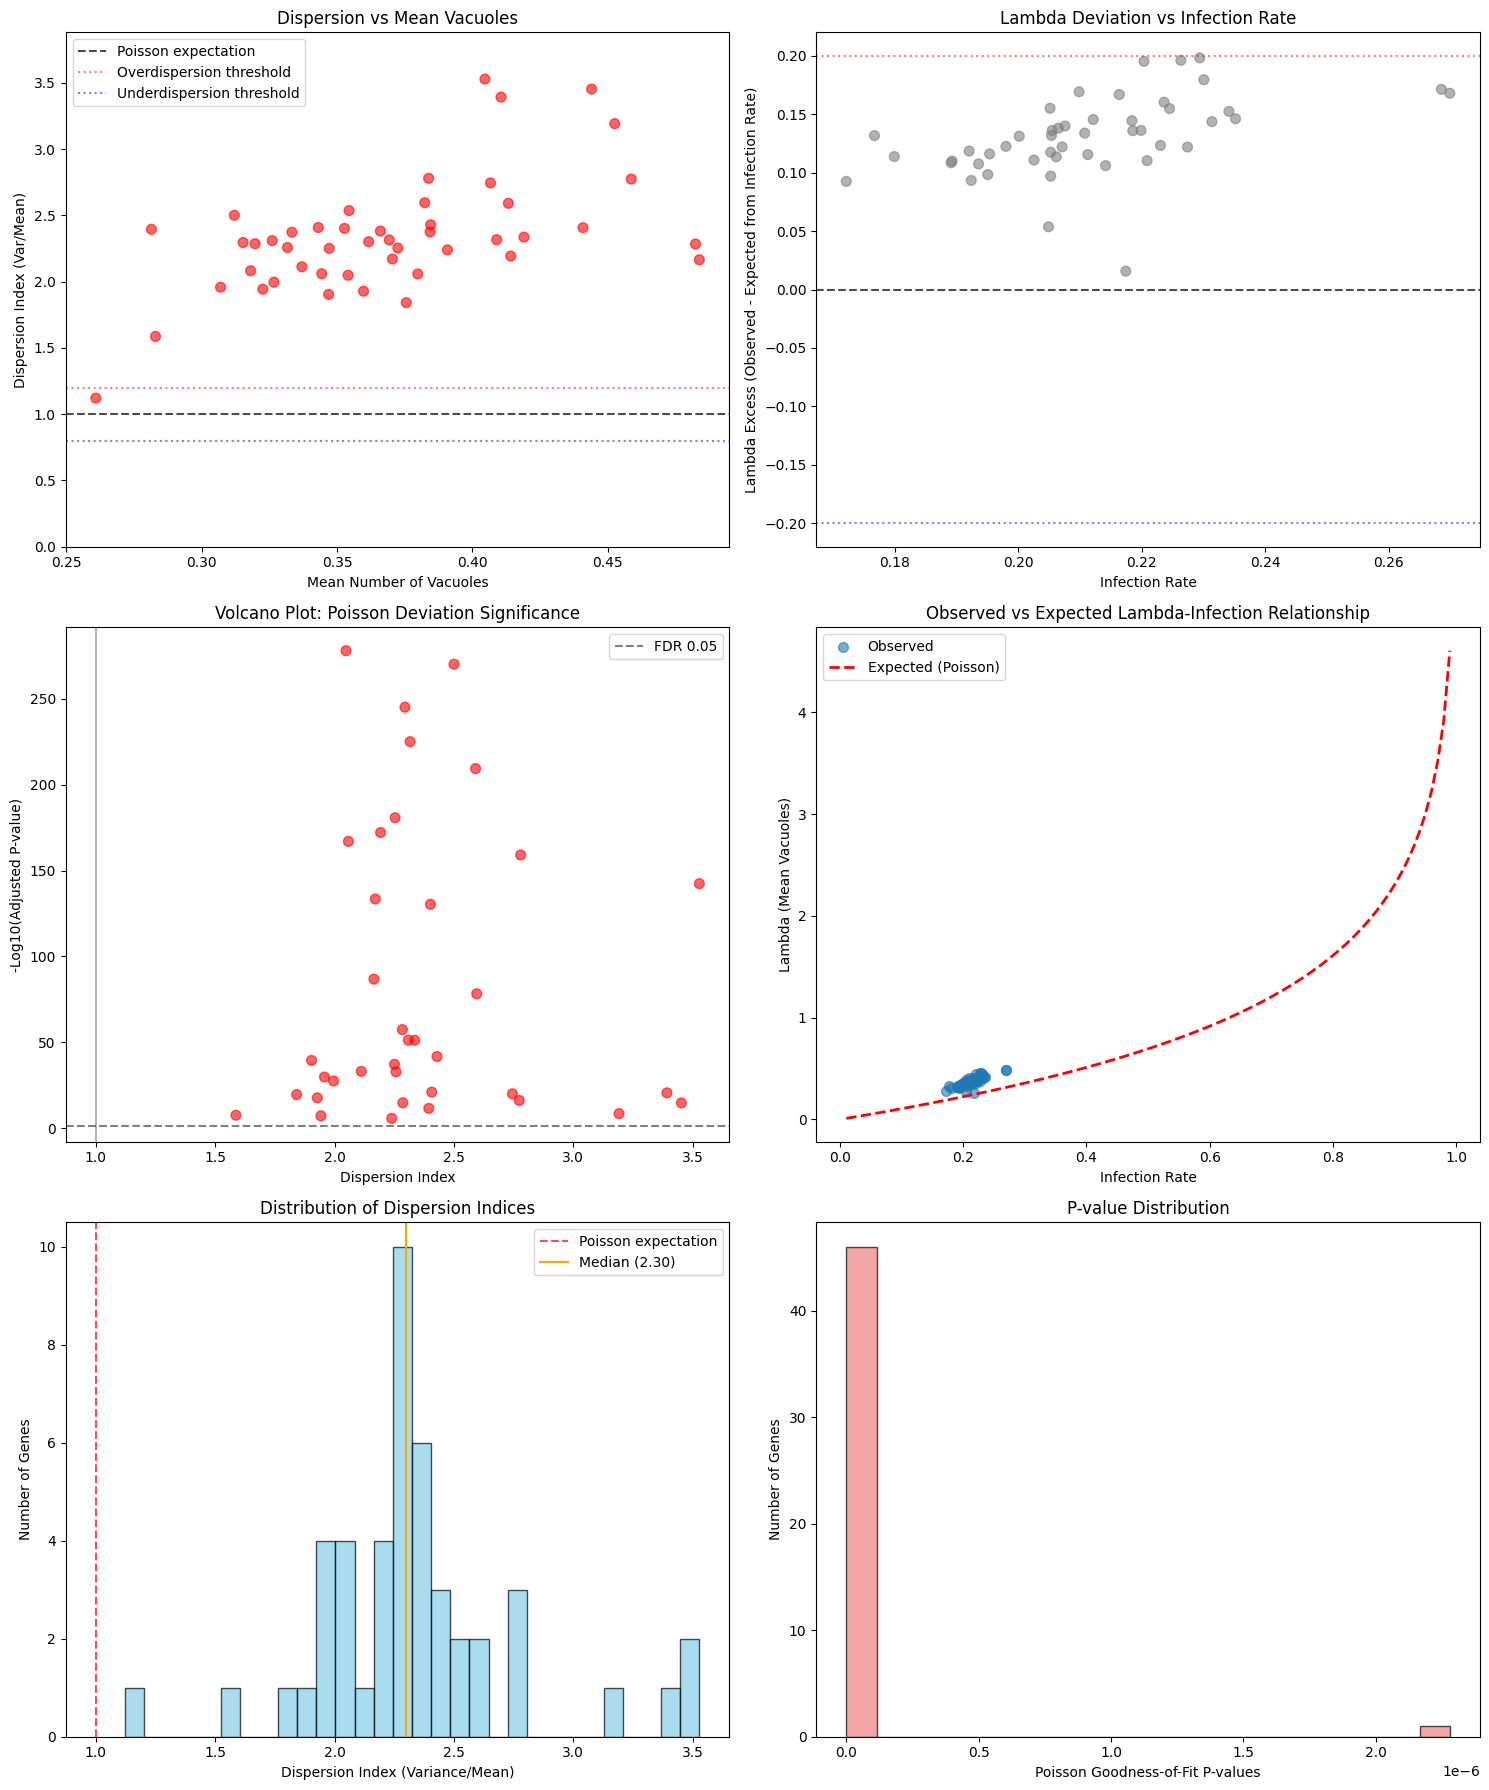


Results exported to 'poisson_deviation_analysis_results.csv'
Total genes tested: 47
Genes with significant Poisson deviations: 47
Control baseline infection rate: 0.216
Control baseline lambda: 0.380

Summary of effect classifications:
  Significant_overdispersion: 46 genes
  No_significant_effect: 1 genes


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import poisson, chi2_contingency, kstest, chisquare, ttest_1samp
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar

# Create vacuole categories for visualization
merge['vacuole_category'] = pd.cut(merge['num_vacuoles'], 
                                   bins=[-0.5, 0.5, 1.5, 2.5, np.inf], 
                                   labels=['0_vacuoles', '1_vacuole', '2_vacuoles', '3plus_vacuoles'])

# Create summary statistics by gene for numerical columns
summary_numeric = merge.groupby('gene_symbol_0').agg({
    'num_vacuoles': ['count', 'mean', 'std', 'var']
}).round(4)

# Flatten column names
summary_numeric.columns = ['total_cells', 'mean_vacuoles', 'std_vacuoles', 'var_vacuoles']

# Create category counts separately
category_counts = merge.groupby(['gene_symbol_0', 'vacuole_category']).size().unstack(fill_value=0)

# Ensure all category columns exist
for col in ['0_vacuoles', '1_vacuole', '2_vacuoles', '3plus_vacuoles']:
    if col not in category_counts.columns:
        category_counts[col] = 0

# Combine numeric summary with category counts
summary = pd.concat([summary_numeric, category_counts], axis=1)

# Calculate percentages
summary['pct_0_vacuoles'] = (summary['0_vacuoles'] / summary['total_cells']) * 100
summary['pct_1_vacuole'] = (summary['1_vacuole'] / summary['total_cells']) * 100
summary['pct_2_vacuoles'] = (summary['2_vacuoles'] / summary['total_cells']) * 100
summary['pct_3plus_vacuoles'] = (summary['3plus_vacuoles'] / summary['total_cells']) * 100

# Calculate infection rate (proportion of cells with >= 1 vacuole)
summary['infection_rate'] = 1 - (summary['0_vacuoles'] / summary['total_cells'])
summary['pct_infected'] = summary['infection_rate'] * 100

# Identify nontargeting controls
controls = summary[summary.index.str.contains('nontargeting', na=False)]
print(f"Found {len(controls)} nontargeting controls:")
print(controls[['total_cells', 'mean_vacuoles', 'pct_infected', 'var_vacuoles']])

# Calculate pooled control statistics
control_mean_lambda = controls['mean_vacuoles'].mean()
control_mean_infection_rate = controls['infection_rate'].mean()
control_var_lambda = controls['var_vacuoles'].mean()

print(f"\nPooled control baseline:")
print(f"  Mean infection rate: {control_mean_infection_rate:.3f} ({control_mean_infection_rate*100:.1f}%)")
print(f"  Mean lambda (vacuoles per cell): {control_mean_lambda:.3f}")
print(f"  Mean variance: {control_var_lambda:.3f}")
print(f"  Expected Poisson variance: {control_mean_lambda:.3f}")

# Filter genes for testing
genes_to_test = summary[(summary['total_cells'] >= 20)]  # Require more cells for Poisson testing
print(f"\nTesting {len(genes_to_test)} genes with ≥20 cells")

def fit_poisson_lambda(gene_data):
    """Fit Poisson parameter lambda using MLE"""
    if len(gene_data) == 0:
        return np.nan
    return np.mean(gene_data)

def calculate_poisson_expected_counts(lambda_param, total_cells, max_vacuoles=10):
    """Calculate expected counts under Poisson distribution"""
    expected_counts = []
    for k in range(max_vacuoles):
        if k < max_vacuoles - 1:
            prob = poisson.pmf(k, lambda_param)
        else:
            # Lump all higher counts into the last category
            prob = 1 - poisson.cdf(k-1, lambda_param)
        expected_counts.append(prob * total_cells)
    return np.array(expected_counts)

def poisson_goodness_of_fit_test(observed_counts, lambda_param):
    """Perform chi-square goodness of fit test against Poisson"""
    total_cells = np.sum(observed_counts)
    max_category = len(observed_counts)
    
    # Calculate expected counts
    expected_counts = calculate_poisson_expected_counts(lambda_param, total_cells, max_category)
    
    # Combine categories with expected counts < 5 to satisfy chi-square assumptions
    combined_observed = []
    combined_expected = []
    temp_obs = 0
    temp_exp = 0
    
    for obs, exp in zip(observed_counts, expected_counts):
        temp_obs += obs
        temp_exp += exp
        if temp_exp >= 5 or (obs == observed_counts[-1] and exp == expected_counts[-1]):
            combined_observed.append(temp_obs)
            combined_expected.append(temp_exp)
            temp_obs = 0
            temp_exp = 0
    
    if len(combined_observed) < 2:
        return np.nan, np.nan, np.nan
    
    # Perform chi-square test
    chi2_stat, p_value = chisquare(combined_observed, combined_expected, ddof=1)  # ddof=1 because lambda is estimated
    
    return chi2_stat, p_value, len(combined_observed)

# Perform Poisson deviation analysis
results = []

for gene in genes_to_test.index:
    # Get raw data for this gene
    gene_mask = merge['gene_symbol_0'] == gene
    gene_vacuole_data = merge.loc[gene_mask, 'num_vacuoles'].values
    
    if len(gene_vacuole_data) < 20:  # Skip genes with too few cells
        continue
    
    # Basic statistics
    total_cells = len(gene_vacuole_data)
    mean_vacuoles = np.mean(gene_vacuole_data)
    var_vacuoles = np.var(gene_vacuole_data, ddof=1)
    std_vacuoles = np.std(gene_vacuole_data, ddof=1)
    
    # Infection rate
    infection_rate = np.mean(gene_vacuole_data > 0)
    
    # Fit Poisson lambda
    lambda_fitted = fit_poisson_lambda(gene_vacuole_data)
    
    # Calculate observed counts (up to some reasonable maximum)
    max_vacuoles = min(int(np.max(gene_vacuole_data)) + 1, 10)
    observed_counts = np.array([np.sum(gene_vacuole_data == k) for k in range(max_vacuoles-1)])
    observed_counts = np.append(observed_counts, np.sum(gene_vacuole_data >= max_vacuoles-1))
    
    # Poisson goodness of fit test
    chi2_stat, poisson_p_value, effective_categories = poisson_goodness_of_fit_test(observed_counts, lambda_fitted)
    
    # Overdispersion metrics
    dispersion_index = var_vacuoles / mean_vacuoles if mean_vacuoles > 0 else np.nan
    
    # Poisson predictions given observed lambda
    expected_infection_rate = 1 - poisson.pmf(0, lambda_fitted)
    
    # Compare to control-based expectations
    # Estimate what lambda should be given the infection rate and assuming Poisson
    def lambda_from_infection_rate(infection_rate):
        if infection_rate <= 0:
            return 0
        elif infection_rate >= 1:
            return 10  # Some reasonable upper bound
        else:
            # Solve: 1 - exp(-lambda) = infection_rate
            return -np.log(1 - infection_rate)
    
    expected_lambda_from_infection = lambda_from_infection_rate(infection_rate)
    
    # Test if lambda is higher or lower than expected from infection rate alone
    lambda_excess = lambda_fitted - expected_lambda_from_infection
    
    # Effect size: how much does this deviate from control expectations?
    fold_change_lambda = lambda_fitted / control_mean_lambda if control_mean_lambda > 0 else np.nan
    fold_change_infection = infection_rate / control_mean_infection_rate if control_mean_infection_rate > 0 else np.nan
    
    # Statistical tests for dispersion and lambda excess
    # Test for overdispersion vs Poisson expectation (using F-test approximation)
    if mean_vacuoles > 0:
        # Test if variance is significantly different from mean (Poisson assumption)
        # Using a modified F-test for variance ratio
        f_stat = var_vacuoles / mean_vacuoles
        df1 = total_cells - 1
        df2 = 1e6  # Large df for Poisson (essentially chi-square/df)
        dispersion_p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))
    else:
        dispersion_p_value = np.nan
    
    # Test if lambda_excess is significantly different from 0
    # Using bootstrap or normal approximation
    if total_cells > 30:  # Use normal approximation for lambda excess
        # Standard error of lambda estimate
        lambda_se = np.sqrt(lambda_fitted / total_cells)
        # Z-test for lambda excess
        if lambda_se > 0:
            z_stat = lambda_excess / lambda_se
            lambda_excess_p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        else:
            lambda_excess_p_value = np.nan
    else:
        lambda_excess_p_value = np.nan
    
    results.append({
        'gene': gene,
        'total_cells': total_cells,
        'mean_vacuoles': mean_vacuoles,
        'var_vacuoles': var_vacuoles,
        'std_vacuoles': std_vacuoles,
        'infection_rate': infection_rate,
        'pct_infected': infection_rate * 100,
        'lambda_fitted': lambda_fitted,
        'expected_lambda_from_infection': expected_lambda_from_infection,
        'lambda_excess': lambda_excess,
        'dispersion_index': dispersion_index,
        'expected_infection_rate': expected_infection_rate,
        'poisson_chi2': chi2_stat,
        'poisson_p_value': poisson_p_value,
        'dispersion_p_value': dispersion_p_value,
        'lambda_excess_p_value': lambda_excess_p_value,
        'effective_categories': effective_categories,
        'fold_change_lambda': fold_change_lambda,
        'fold_change_infection': fold_change_infection,
        'log2_fc_lambda': np.log2(fold_change_lambda) if fold_change_lambda > 0 else np.nan,
        'log2_fc_infection': np.log2(fold_change_infection) if fold_change_infection > 0 else np.nan,
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply multiple testing correction for all p-values
p_value_columns = ['poisson_p_value', 'dispersion_p_value', 'lambda_excess_p_value']

for col in p_value_columns:
    valid_p_values = ~results_df[col].isna()
    if valid_p_values.sum() > 0:
        adj_col = col.replace('_p_value', '_p_adj')
        results_df.loc[valid_p_values, adj_col] = multipletests(
            results_df.loc[valid_p_values, col], method='fdr_bh')[1]
    else:
        adj_col = col.replace('_p_value', '_p_adj')
        results_df[adj_col] = np.nan

# Sort by Poisson deviation significance
results_df = results_df.sort_values('poisson_p_value', na_position='last')

# Add significance and effect classifications
results_df['significant_poisson_deviation'] = (results_df['poisson_p_adj'] < 0.05) & (~results_df['poisson_p_adj'].isna())
results_df['significant_dispersion'] = (results_df['dispersion_p_adj'] < 0.05) & (~results_df['dispersion_p_adj'].isna())
results_df['significant_lambda_excess'] = (results_df['lambda_excess_p_adj'] < 0.05) & (~results_df['lambda_excess_p_adj'].isna())

results_df['overdispersed'] = results_df['dispersion_index'] > 1.2  # Threshold for overdispersion
results_df['underdispersed'] = results_df['dispersion_index'] < 0.8  # Threshold for underdispersion

# Define lambda excess categories
lambda_excess_threshold = 0.2
results_df['high_lambda_excess'] = (results_df['lambda_excess'] > lambda_excess_threshold) & results_df['significant_lambda_excess']
results_df['low_lambda_excess'] = (results_df['lambda_excess'] < -lambda_excess_threshold) & results_df['significant_lambda_excess']

# Classify effects based on statistical significance
results_df['vacuole_effect'] = 'No_significant_effect'
results_df.loc[results_df['significant_poisson_deviation'] & results_df['overdispersed'], 'vacuole_effect'] = 'Significant_overdispersion'
results_df.loc[results_df['significant_poisson_deviation'] & results_df['underdispersed'], 'vacuole_effect'] = 'Significant_underdispersion'
results_df.loc[results_df['high_lambda_excess'], 'vacuole_effect'] = 'Significant_high_lambda'
results_df.loc[results_df['low_lambda_excess'], 'vacuole_effect'] = 'Significant_low_lambda'

# Combined significance flag
results_df['any_significant_effect'] = (results_df['significant_poisson_deviation'] | 
                                       results_df['significant_dispersion'] | 
                                       results_df['significant_lambda_excess'])

# Display results
print("\n" + "="*100)
print("POISSON DEVIATION ANALYSIS RESULTS (WITH MULTIPLE TESTING CORRECTION)")
print("="*100)

print(f"\nMultiple testing correction applied using Benjamini-Hochberg (FDR) method")
print(f"Genes with significant Poisson deviations (FDR < 0.05): {results_df['significant_poisson_deviation'].sum()}")
print(f"Genes with significant dispersion differences (FDR < 0.05): {results_df['significant_dispersion'].sum()}")
print(f"Genes with significant lambda excess (FDR < 0.05): {results_df['significant_lambda_excess'].sum()}")
print(f"Genes with any significant effect: {results_df['any_significant_effect'].sum()}")

print(f"\nStatistically significant effects:")
print(f"  Overdispersed genes: {results_df['overdispersed'].sum()}")
print(f"  Underdispersed genes: {results_df['underdispersed'].sum()}")
print(f"  High lambda excess genes: {results_df['high_lambda_excess'].sum()}")
print(f"  Low lambda excess genes: {results_df['low_lambda_excess'].sum()}")

# Show top results for different categories
any_sig = results_df[results_df['any_significant_effect']]
if len(any_sig) > 0:
    print(f"\nTop 10 genes with any significant effect:")
    display_cols = ['gene', 'mean_vacuoles', 'infection_rate', 'dispersion_index', 'lambda_excess', 
                   'poisson_p_adj', 'dispersion_p_adj', 'lambda_excess_p_adj', 'vacuole_effect']
    print(any_sig[display_cols].head(10).to_string(index=False))

sig_poisson = results_df[results_df['significant_poisson_deviation']]
if len(sig_poisson) > 0:
    print(f"\nTop 10 genes with significant Poisson deviations:")
    display_cols = ['gene', 'mean_vacuoles', 'dispersion_index', 'poisson_p_value', 'poisson_p_adj']
    print(sig_poisson[display_cols].head(10).to_string(index=False))

sig_dispersion = results_df[results_df['significant_dispersion']]
if len(sig_dispersion) > 0:
    print(f"\nTop 10 genes with significant dispersion effects:")
    display_cols = ['gene', 'mean_vacuoles', 'var_vacuoles', 'dispersion_index', 'dispersion_p_adj']
    print(sig_dispersion[display_cols].head(10).to_string(index=False))

sig_lambda_excess = results_df[results_df['significant_lambda_excess']]
if len(sig_lambda_excess) > 0:
    print(f"\nTop 10 genes with significant lambda excess:")
    display_cols = ['gene', 'infection_rate', 'lambda_fitted', 'lambda_excess', 'lambda_excess_p_adj']
    print(sig_lambda_excess[display_cols].head(10).to_string(index=False))

print(f"\nTop 20 results by Poisson deviation significance:")
display_cols = ['gene', 'total_cells', 'mean_vacuoles', 'infection_rate', 'dispersion_index', 'poisson_p_value', 'significant_poisson_deviation']
print(results_df[display_cols].head(20).to_string(index=False))

# Create comprehensive visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# 1. Dispersion index vs mean vacuoles
ax1 = axes[0, 0]
colors = ['red' if sig else 'blue' if over else 'green' if under else 'gray' 
          for sig, over, under in zip(results_df['significant_poisson_deviation'], 
                                     results_df['overdispersed'], 
                                     results_df['underdispersed'])]

scatter = ax1.scatter(results_df['mean_vacuoles'], results_df['dispersion_index'], 
                     c=colors, alpha=0.6, s=50)
ax1.axhline(1, color='black', linestyle='--', alpha=0.7, label='Poisson expectation')
ax1.axhline(1.2, color='red', linestyle=':', alpha=0.5, label='Overdispersion threshold')
ax1.axhline(0.8, color='blue', linestyle=':', alpha=0.5, label='Underdispersion threshold')
ax1.set_xlabel('Mean Number of Vacuoles')
ax1.set_ylabel('Dispersion Index (Var/Mean)')
ax1.set_title('Dispersion vs Mean Vacuoles')
ax1.legend()
ax1.set_ylim(0, min(5, results_df['dispersion_index'].max() * 1.1))

# 2. Lambda excess vs infection rate
ax2 = axes[0, 1]
colors2 = ['red' if excess > 0.2 else 'blue' if excess < -0.2 else 'gray' 
           for excess in results_df['lambda_excess']]
ax2.scatter(results_df['infection_rate'], results_df['lambda_excess'], 
           c=colors2, alpha=0.6, s=50)
ax2.axhline(0, color='black', linestyle='--', alpha=0.7)
ax2.axhline(0.2, color='red', linestyle=':', alpha=0.5)
ax2.axhline(-0.2, color='blue', linestyle=':', alpha=0.5)
ax2.set_xlabel('Infection Rate')
ax2.set_ylabel('Lambda Excess (Observed - Expected from Infection Rate)')
ax2.set_title('Lambda Deviation vs Infection Rate')

# 3. Volcano plot - Poisson deviation
ax3 = axes[1, 0]
valid_p = ~results_df['poisson_p_adj'].isna()
plot_data = results_df[valid_p]
colors3 = ['red' if sig else 'gray' for sig in plot_data['significant_poisson_deviation']]

ax3.scatter(plot_data['dispersion_index'], -np.log10(plot_data['poisson_p_adj']), 
           c=colors3, alpha=0.6, s=50)
ax3.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5, label='FDR 0.05')
ax3.axvline(1, color='black', linestyle='-', alpha=0.3)
ax3.set_xlabel('Dispersion Index')
ax3.set_ylabel('-Log10(Adjusted P-value)')
ax3.set_title('Volcano Plot: Poisson Deviation Significance')
ax3.legend()

# 4. Infection rate vs lambda comparison
ax4 = axes[1, 1]
ax4.scatter(results_df['infection_rate'], results_df['lambda_fitted'], alpha=0.6, s=50, label='Observed')

# Plot expected relationship
infection_range = np.linspace(0.01, 0.99, 100)
expected_lambda = [-np.log(1-ir) for ir in infection_range]
ax4.plot(infection_range, expected_lambda, 'r--', label='Expected (Poisson)', linewidth=2)

ax4.set_xlabel('Infection Rate')
ax4.set_ylabel('Lambda (Mean Vacuoles)')
ax4.set_title('Observed vs Expected Lambda-Infection Relationship')
ax4.legend()

# 5. Distribution of dispersion indices
ax5 = axes[2, 0]
ax5.hist(results_df['dispersion_index'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax5.axvline(1, color='red', linestyle='--', alpha=0.7, label='Poisson expectation')
ax5.axvline(results_df['dispersion_index'].median(), color='orange', linestyle='-', 
           label=f'Median ({results_df["dispersion_index"].median():.2f})')
ax5.set_xlabel('Dispersion Index (Variance/Mean)')
ax5.set_ylabel('Number of Genes')
ax5.set_title('Distribution of Dispersion Indices')
ax5.legend()

# 6. P-value distribution
ax6 = axes[2, 1]
valid_p_values = results_df['poisson_p_value'].dropna()
ax6.hist(valid_p_values, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
ax6.set_xlabel('Poisson Goodness-of-Fit P-values')
ax6.set_ylabel('Number of Genes')
ax6.set_title('P-value Distribution')

plt.tight_layout()
plt.show()

# Export results
results_df.to_csv('/lab/ops_analysis/lourido/nebo-analysis/output_analysis/merge/poisson_deviation_analysis_results.csv', index=False)
print(f"\nResults exported to 'poisson_deviation_analysis_results.csv'")
print(f"Total genes tested: {len(results_df)}")
print(f"Genes with significant Poisson deviations: {results_df['significant_poisson_deviation'].sum()}")
print(f"Control baseline infection rate: {control_mean_infection_rate:.3f}")
print(f"Control baseline lambda: {control_mean_lambda:.3f}")

# Summary of different effect types
print(f"\nSummary of effect classifications:")
effect_summary = results_df['vacuole_effect'].value_counts()
for effect, count in effect_summary.items():
    print(f"  {effect}: {count} genes")

In [13]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact

# Count how many rows have has_vacuole True/False for each gene
counts = (
    merge
    .groupby(["gene_symbol_0", "has_vacuole"], dropna=False)
    .size()
    .unstack(fill_value=0)
)

# Add % True
counts["pct_true"] = counts[True] / (counts[True] + counts[False]) * 100

# Reference: pooled nontargeting controls
ref_controls = counts.loc[counts.index.astype(str).str.startswith("nontargeting")].sum()

results = []

for gene, row in counts.iterrows():
    if pd.isna(gene):  # skip NA
        continue
    
    count = row[True]
    nobs = row[True] + row[False]

    # control counts
    ctrl_count = ref_controls[True]
    ctrl_nobs = ref_controls[True] + ref_controls[False]

    # contingency table for Fisher
    table = [[count, nobs - count],
             [ctrl_count, ctrl_nobs - ctrl_count]]

    # small counts → Fisher's exact test
    if nobs < 30 or ctrl_nobs < 30:
        _, pval_ctrl = fisher_exact(table)
    else:
        _, pval_ctrl = proportions_ztest([count, ctrl_count],
                                         [nobs, ctrl_nobs])

    results.append({
        "gene_symbol_0": gene,
        "pct_true": row["pct_true"],
        "pval_vs_nontargeting": pval_ctrl
    })

# Convert results → DataFrame
results_df = pd.DataFrame(results).drop(columns=["pct_true"], errors="ignore")

# FDR correction
results_df["qval_vs_nontargeting"] = multipletests(
    results_df["pval_vs_nontargeting"], method="fdr_bh"
)[1]

# Merge results into counts (pct_true from counts is preserved)
counts = counts.merge(results_df.set_index("gene_symbol_0"),
                      left_index=True, right_index=True, how="left")

# Sort by % vacuolated (descending)
counts = counts.sort_values("pct_true", ascending=False)


# Save
counts.to_csv(
    "/lab/ops_analysis/lourido/nebo-analysis/output_analysis/merge/vacuole_enrichment_by_gene.csv"
)

print(counts.head(20))


                      False  True   pct_true  pval_vs_nontargeting  \
gene_symbol_0                                                        
PMVK                    395   146  26.987061              0.002103   
IDO1                    771   283  26.850095              0.000115   
SLC7A1                 1444   444  23.516949              0.041898   
MYC                     530   162  23.410405              0.165832   
NOS2                    412   124  23.134328              0.267296   
nontargeting_CGCTTAT     10     3  23.076923              0.742292   
MSMO1                   241    72  23.003195              0.408132   
MGAT1                   168    50  22.935780              0.497216   
SAMM50                  598   176  22.739018              0.294071   
nontargeting_TAGTGCA    147    43  22.631579              0.590608   
IMMT                   1223   354  22.447685              0.261708   
EIF2AK4                1330   383  22.358435              0.279509   
SOAT1               

In [99]:
import pandas as pd

# df = pd.read_parquet("your_file.parquet")

# Count occurrences
counts = merge_formatted["gene_symbol_0"].value_counts()

# Average frequency across unique gene symbols
average_count = counts.median()

print("Average count per gene_symbol_0:", average_count)


Average count per gene_symbol_0: 910.0


In [101]:
# Count frequency of each unique value in 'gene_symbol_0'
counts = merge_formatted["gene_symbol_0"].value_counts()

print(counts)

gene_symbol_0
SNX5                    5181
RIPK3                   4077
PTPA                    3562
STAT3                   3426
TPSG1                   3108
GRIA4                   2992
CDKN1A                  2810
STAT6                   2302
SLC7A1                  2281
SLC35A2                 2192
EIF2AK4                 2051
IMMT                    1914
UHRF1                   1836
VPS4A                   1758
TOMM70                  1670
TSG101                  1481
MOSPD2                  1366
IDO1                    1358
F2RL2                   1180
SSB                     1164
GBP5                    1135
nontargeting_CCAGCTT    1049
nontargeting_CTCGACT    1010
nontargeting_CTACAGT     995
SAMM50                   910
PDCD6IP                  884
ZBP1                     853
MYC                      836
STAT2                    833
PPIL2                    784
PMVK                     699
NOS2                     698
USP7                     652
ATF4                     650


In [77]:
# Let's check the current state of your dataset
merge_formatted = pd.read_parquet('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/parquets/P-1_W-A3__merge_final.parquet')
print("=== CURRENT DATASET STATE ===")
print(f"merge_formatted shape: {merge_formatted.shape}")
print(f"Total rows: {len(merge_formatted)}")
print(f"Memory usage: {merge_formatted.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n=== GENE SYMBOL COUNTS ===")
current_counts = merge_formatted["gene_symbol_0"].value_counts()
print(f"Unique genes: {len(current_counts)}")
print(f"Total count sum: {current_counts.sum()}")
print("Top genes:")
print(current_counts.head(10))

print("\n=== DATA SAMPLE ===")
print(merge_formatted.head())

print("\n=== CHECKING FOR FILTERS ===")
# Check if there are any obvious filters applied
print(f"Unique values in key columns:")
for col in merge_formatted.columns:
    if merge_formatted[col].dtype == 'object' or merge_formatted[col].dtype.name.startswith('int') or merge_formatted[col].dtype.name.startswith('bool'):
        unique_vals = merge_formatted[col].nunique()
        if unique_vals < 20:  # Only show columns with few unique values
            print(f"  {col}: {unique_vals} unique values - {list(merge_formatted[col].unique())}")
        else:
            print(f"  {col}: {unique_vals} unique values")

=== CURRENT DATASET STATE ===
merge_formatted shape: (106962, 4169)
Total rows: 106962
Memory usage: 3440.94 MB

=== GENE SYMBOL COUNTS ===
Unique genes: 46
Total count sum: 41925
Top genes:
gene_symbol_0
SNX5       6465
PTPA       5333
VPS4A      4436
GRIA4      3507
EIF2AK4    2855
STAT6      2433
TPSG1      2148
IDO1       1318
SSB        1222
RIPK3       969
Name: count, dtype: Int64

=== DATA SAMPLE ===
   plate well  site  tile  cell_0           i_0           j_0  cell_1  \
0      1   A3   194  6592       3  10671.387178  24290.593852     790   
1      1   A3   440  6592       4  14207.292796  13061.813114     275   
2      1   A3   451  6592      10   8335.858837  10980.066078     168   
3      1   A3   451  6592      11  18925.379396  18821.120439     138   
4      1   A3   451  6592       9  20129.888246  13182.599536      95   

            i_1           j_1  ...  cytoplasm_second_neighbor_distance  \
0  10671.388889  24290.611111  ...                          699.013867   
1

In [1]:
import pandas as pd
info = pd.read_parquet('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/parquets/P-1_W-A3__merge_final.parquet')
# vacuoles = pd.read_parquet('/lab/ops_analysis/lourido/nebo/nebo_MIP/analysis/brieflow_output/phenotype/parquets/P-1_W-A3__phenotype_vacuoles.parquet')


In [2]:

info

,plate,well,site,tile,cell_0,i_0,j_0,cell_1,i_1,j_1,...,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors,cell_area_y,has_vacuole,num_vacuoles,vacuole_ids,total_vacuole_area,vacuole_area_ratio,mean_vacuole_diameter,mean_distance_to_nucleus
0,1,A3,191,2616,14,10397.237022,25822.730503,368,10397.228261,25822.760870,...,197.607809,18.531850,6500,False,0,[],0,0.000000,NaN,NaN
1,1,A3,89,1353,3,6580.332070,13132.112296,278,6580.376623,13132.129870,...,208.105642,135.822991,25700,False,0,[],0,0.000000,NaN,NaN
2,1,A3,216,3258,14,12782.133600,1708.769511,52,12782.141509,1708.707547,...,85.135055,125.799029,16800,True,2,"[7, 13]",4425,0.263393,53.064712,80.875237
3,1,A3,251,3675,20,14099.156013,10930.733151,180,14099.176166,10930.803109,...,258.017262,66.321668,44700,False,0,[],0,0.000000,NaN,NaN
4,1,A3,181,2759,11,11185.055331,14603.250296,366,11185.142180,14603.246445,...,305.778433,58.328224,57600,True,1,[10],1404,0.024375,42.280354,60.006822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94169,1,A3,260,3826,12,14773.895286,892.255314,375,14756.087963,901.356481,...,283.680965,177.519838,20000,False,0,[],0,0.000000,NaN,NaN
94170,1,A3,401,6132,2,22169.042170,12365.261824,53,22188.978355,12363.683983,...,476.896885,74.387228,20400,False,0,[],0,0.000000,NaN,NaN
94171,1,A3,50,678,6,4062.568438,13425.703653,194,4042.855932,13429.076271,...,884.595826,53.020623,97200,True,3,"[2, 16, 20]",3038,0.031255,32.395277,60.771062
94172,1,A3,420,6259,7,22947.315495,13195.060764,8,22967.100775,13197.976744,...,584.522882,172.886118,20900,False,0,[],0,0.000000,NaN,NaN


In [7]:
vacuoles

,vacuole_id,cell_id,plate,well,tile,distance_to_nucleus,nearest_nucleus_id,overlap_ratio,vacuole_diameter,vacuole_DAPI_int,...,vacuole_bounds_0,vacuole_bounds_1,vacuole_bounds_2,vacuole_bounds_3,vacuole_number_neighbors_1,vacuole_percent_touching_1,vacuole_first_neighbor_distance,vacuole_second_neighbor_distance,vacuole_angle_between_neighbors,vacuole_area
0,1.0,7.0,1.0,A3,0.0,102.924987,6.0,0.694627,109.714204,1312170.0,...,218.0,1223.0,339.0,1339.0,2.0,0.272727,81.166900,85.737430,138.037418,9454.0
1,2.0,7.0,1.0,A3,0.0,59.964821,6.0,1.000000,71.123700,694757.0,...,274.0,1313.0,344.0,1399.0,2.0,0.396226,69.772162,81.166900,157.516228,3973.0
2,3.0,12.0,1.0,A3,0.0,144.645068,11.0,0.269508,63.740940,420508.0,...,354.0,1835.0,417.0,1914.0,1.0,0.091873,74.521783,265.173500,10.786901,3191.0
3,4.0,18.0,1.0,A3,0.0,72.174741,17.0,0.786731,88.705244,800698.0,...,629.0,2043.0,693.0,2187.0,0.0,0.000000,127.831344,147.536711,67.000959,6180.0
4,5.0,9.0,1.0,A3,0.0,98.759602,13.0,1.000000,67.608653,498587.0,...,431.0,1518.0,506.0,1591.0,0.0,0.000000,66.992171,121.715732,148.452252,3590.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1.0,5.0,1.0,A3,6143.0,54.105782,4.0,0.987050,42.069026,535954.0,...,1818.0,107.0,1876.0,152.0,0.0,0.000000,NaN,NaN,NaN,1390.0
0,1.0,6.0,1.0,A3,6395.0,48.933294,5.0,0.746255,159.153472,8336363.0,...,795.0,1087.0,953.0,1275.0,0.0,0.000000,580.111294,1019.602801,166.458817,19894.0
1,3.0,13.0,1.0,A3,6395.0,52.521248,12.0,1.000000,30.024217,142209.0,...,1858.0,2027.0,1888.0,2062.0,0.0,0.000000,1046.605615,1321.471182,25.088775,708.0
2,6.0,5.0,1.0,A3,6395.0,37.310559,4.0,1.000000,16.583719,114412.0,...,651.0,169.0,671.0,186.0,0.0,0.000000,1019.602801,1589.402700,4.902454,216.0


In [10]:
import pandas as pd
info = pd.read_parquet('/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/sbs/parquets/P-1_W-A3__sbs_info.parquet')

In [1]:
sbs_path = '/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/sbs/parquets/P-1_W-A3__cells.parquet'

In [ ]:
import pandas as pd
sbs = pd.read_parquet(sbs_path)

In [4]:
import pandas as pd
merge_final_path = '/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/parquets/P-1_W-A3__merge_final.parquet'
merge_final = pd.read_parquet(merge_final_path)
merge_final

,plate,well,site,tile,cell_0,cell_1,global_i_0,global_j_0,global_i_1,global_j_1,...,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors,cell_area_y,has_vacuole,num_vacuoles,vacuole_ids,total_vacuole_area,vacuole_area_ratio,mean_vacuole_diameter,mean_distance_to_nucleus
0,1,A3,191,2616,14,368,10397.237022,25822.730503,10397.228261,25822.760870,...,197.607809,18.531850,6500,False,0,[],0,0.000000,NaN,NaN
1,1,A3,89,1353,3,278,6580.332070,13132.112296,6580.376623,13132.129870,...,208.105642,135.822991,25700,False,0,[],0,0.000000,NaN,NaN
2,1,A3,216,3258,14,52,12782.133600,1708.769511,12782.141509,1708.707547,...,85.135055,125.799029,16800,True,2,"[7, 13]",4425,0.263393,53.064712,80.875237
3,1,A3,251,3675,20,180,14099.156013,10930.733151,14099.176166,10930.803109,...,258.017262,66.321668,44700,False,0,[],0,0.000000,NaN,NaN
4,1,A3,181,2759,11,366,11185.055331,14603.250296,11185.142180,14603.246445,...,305.778433,58.328224,57600,True,1,[10],1404,0.024375,42.280354,60.006822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65475,1,A3,151,2455,7,578,10232.920707,20511.949874,10243.632768,20517.355932,...,447.323568,30.340797,49500,False,0,[],0,0.000000,NaN,NaN
65476,1,A3,212,2901,19,136,11889.798877,2457.328174,11888.344660,2445.417476,...,334.440534,153.948956,19900,True,1,[6],2321,0.116633,54.361650,69.722574
65477,1,A3,58,787,2,591,4510.279934,21704.569685,4499.922374,21710.627854,...,284.856019,27.606319,176400,True,4,"[1, 6, 9, 13]",7099,0.040244,43.374523,188.399138
65478,1,A3,310,4920,18,377,18140.591090,4568.011902,18141.962810,4556.090909,...,263.566162,123.851387,49600,False,0,[],0,0.000000,NaN,NaN


In [7]:
merge_formatted_path = '/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/parquets/P-1_W-A3__merge_formatted.parquet'

In [8]:
merge_formatted = pd.read_parquet(merge_formatted_path)
merge_formatted

,plate,well,site,tile,cell_0,i_0,j_0,cell_1,i_1,j_1,...,area_0,area_1,stitched_cell_id_0,stitched_cell_id_1,fov_distance_0,fov_distance_1,cell_barcode_0,gene_symbol_0,mapped_single_gene,channels_min
0,1,A3,191,2616,14,10397.237022,25822.730503,368,10397.228261,25822.760870,...,4092,92,56242,95204,25924.614644,26877.629183,ATTTCG,<NA>,None,94
1,1,A3,89,1353,3,6580.332070,13132.112296,278,6580.376623,13132.129870,...,6748,154,21777,34367,12719.477512,13699.448231,CCTGATC,STAT6,True,70
2,1,A3,216,3258,14,12782.133600,1708.769511,52,12782.141509,1708.707547,...,5276,106,76335,113669,11304.448655,12081.041613,CTCGACT,nontargeting_CTCGACT,True,74
3,1,A3,251,3675,20,14099.156013,10930.733151,180,14099.176166,10930.803109,...,9085,193,86157,130539,15765.768474,16802.382445,ATTCAG,<NA>,None,62
4,1,A3,181,2759,11,11185.055331,14603.250296,366,11185.142180,14603.246445,...,9316,211,60653,87585,16322.003471,17357.724424,TCACCCT,STAT3,True,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94169,1,A3,260,3826,12,14773.895286,892.255314,375,14756.087963,901.356481,...,5977,216,89538,135764,13306.881516,14017.016719,CGATACT,TSG101,True,67
94170,1,A3,401,6132,2,22169.042170,12365.261824,53,22188.978355,12363.683983,...,10898,231,130561,172177,23377.882515,24396.079640,TGTTGTC,GRIA4,True,78
94171,1,A3,50,678,6,4062.568438,13425.703653,194,4042.855932,13429.076271,...,13392,236,9623,18332,12221.681369,13111.884454,CATTCAG,MGAT1,True,57
94172,1,A3,420,6259,7,22947.315495,13195.060764,8,22967.100775,13197.976744,...,4995,129,132609,174403,24455.843540,25480.290293,ACTCCT,<NA>,None,62


In [4]:
merged_cells_path = '/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/merge/well_cell_merge/P-1_W-A3__merged_cells.parquet'

In [5]:
import pandas as pd

merged_cells = pd.read_parquet(merged_cells_path)
merged_cells

,plate,well,site,tile,cell_0,cell_1,i_0,j_0,i_1,j_1,area_0,area_1,distance,stitched_cell_id_0,stitched_cell_id_1
0,1,A3,0,103,1,77,1047.248435,18586.374014,1033.010152,18587.868020,5931,197,14.316451,1650,77
1,1,A3,0,102,2,78,1047.922076,18651.807617,1033.118227,18660.118227,5113,203,16.977049,1620,78
2,1,A3,0,102,5,80,1053.186114,18687.405176,1038.949686,18695.094340,4268,159,16.180208,1623,80
3,1,A3,0,102,1,81,1052.091015,18747.043387,1040.596825,18751.542857,7199,315,12.343485,1619,81
4,1,A3,0,102,4,82,1057.058946,18720.365824,1040.687898,18724.853503,7826,314,16.974995,1622,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134517,1,A3,441,6575,19,122,24423.359398,19618.921987,24427.385621,19627.313725,3672,153,9.307618,137645,176351
134518,1,A3,441,6575,23,124,24433.078510,19653.041720,24437.890351,19664.916667,5493,228,12.812813,137649,176353
134519,1,A3,441,6575,26,125,24439.514782,19594.542968,24446.896000,19593.704000,2436,125,7.428744,137652,176354
134520,1,A3,441,6575,36,128,24474.070640,19582.465014,24466.138211,19598.243902,3160,123,17.660599,137662,176357


In [16]:
cells_path = '/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/sbs/parquets/P-1_W-A3__cells.parquet'

In [17]:
sbs_cells = pd.read_parquet(cells_path)
sbs_cells

,cell,plate,tile,well,prefix_recomb,cell_barcode_0,pre_correction_cell_barcode_0,no_recomb_0,peak_0,cell_barcode_1,no_recomb_1,peak_1,gene_symbol_0,gene_symbol_1,Q_min,peak
0,1,1,0,A3,CT,TAGCGTC,TAGGGT,None,757.858774,TGTTGTC,None,41.676381,SSB,GRIA4,None,None
1,2,1,0,A3,GT,TAGCGTC,TAGCGG,None,114.122907,CTCCGTT,None,86.587407,SSB,PTPA,None,None
2,3,1,0,A3,GG,TATCCG,TATCCG,None,462.575564,AGGGGG,None,60.253063,<NA>,<NA>,None,None
3,4,1,0,A3,TG,GATCGG,GATCGG,None,221.917909,CGCTGT,None,200.421759,<NA>,<NA>,None,None
4,5,1,0,A3,GT,TAGCGTC,TTGCGT,None,47.909210,TACGCGA,None,40.365380,SSB,NOS2,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169083,199,1,451,A3,TT,CCAGCTT,CCCGCT,None,53.634641,CTTTCTC,None,53.031926,nontargeting_CCAGCTT,EIF2AK4,None,None
169084,200,1,451,A3,TG,CTCCGTT,ATCCGT,None,93.805045,AGGTCT,None,100.023783,PTPA,<NA>,None,None
169085,201,1,451,A3,TT,TTTCGT,TTTCGT,None,154.351089,<NA>,None,NaN,<NA>,<NA>,None,None
169086,202,1,451,A3,GG,TGTTGTC,TGGTGT,None,124.209665,<NA>,None,NaN,GRIA4,<NA>,None,None


In [19]:
unique_barcodes = sbs_cells.loc[sbs_cells["gene_symbol_0"].notna(), "cell_barcode_0"].unique()
print(unique_barcodes)


<StringArray>
['TAGCGTC', 'TACACTC', 'TCTCGGA', 'CAGTCGT', 'CTTTCTC', 'TGGGTTC', 'TGCCCTA',
 'CAGGCTA', 'CTCCGTT', 'TACGCGA', 'TGTTGTC', 'TAACCGG', 'CTTACGA', 'CCCTATT',
 'TGATGGT', 'CGTGGTT', 'TAGGTGT', 'TGTCTAC', 'TAGTGCA', 'TCCCACA', 'CTCGACT',
 'TGCAACT', 'CTATGTG', 'CTCACAC', 'TACTGAG', 'TCGTCAT', 'CCTGATC', 'TATCAGC',
 'TCACCCT', 'TGGTAAC', 'TCGGATT', 'TCTAGCC', 'CCTTCCT', 'TGGCTCA', 'TACGGCT',
 'TATTCCC', 'TGCGTAG', 'TCCCGAT', 'TAGTAGG', 'CTTTAGG', 'CATGACA', 'CTTGGAA',
 'CAGAAAG', 'TCTGTTG', 'CGATACT', 'CATTCAG', 'CACTAAC', 'CACGCAT', 'TCCTTGC',
 'CGTGAAG', 'TCATCTG', 'CCTCAAT', 'TGAACCA', 'CGACATA', 'TGGAGAA', 'CCAGCTT',
 'CCAAACC', 'CGTCCAA', 'CAACGAC', 'CTACAGT', 'CTGCTCT', 'CGGAACA', 'TGAAAGC',
 'TCGATGA', 'CCCAAGA', 'CAATCCA', 'CCATGGA', 'CATAGCG', 'CCAACAA', 'TCAGGAA',
 'CAGAGTT', 'CTAGAAC', 'CACAGAA', 'CAAGGGT', 'CTAAGGC', 'CAAACTG', 'CGAAGAT',
 'CCACTCA', 'CTCCTAG', 'CGTTTCA', 'CAATTGC', 'CATCTCC', 'CACCTTA', 'CCAATGT',
 'CGAATCG', 'CGCTTAT', 'CTACTTC', 'CGTATGC', 'CCCG

In [ ]:
import pandas as pd
merge_f = pd.read_parquet(merge_formatted)
merge_f

,plate,well,site,tile,cell_0,i_0,j_0,cell_1,i_1,j_1,...,area_0,area_1,stitched_cell_id_0,stitched_cell_id_1,fov_distance_0,fov_distance_1,cell_barcode_0,gene_symbol_0,mapped_single_gene,channels_min
0,1,A3,191,2616,14,10397.237022,25822.730503,368,10397.228261,25822.760870,...,4092,92,56242,95204,25924.614644,26877.629183,ATTTCG,<NA>,None,94
1,1,A3,89,1353,3,6580.332070,13132.112296,278,6580.376623,13132.129870,...,6748,154,21777,34367,12719.477512,13699.448231,CCTGATC,STAT6,True,70
2,1,A3,216,3258,14,12782.133600,1708.769511,52,12782.141509,1708.707547,...,5276,106,76335,113669,11304.448655,12081.041613,CTCGACT,nontargeting_CTCGACT,True,74
3,1,A3,251,3675,20,14099.156013,10930.733151,180,14099.176166,10930.803109,...,9085,193,86157,130539,15765.768474,16802.382445,ATTCAG,<NA>,None,62
4,1,A3,181,2759,11,11185.055331,14603.250296,366,11185.142180,14603.246445,...,9316,211,60653,87585,16322.003471,17357.724424,TCACCCT,STAT3,True,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94169,1,A3,260,3826,12,14773.895286,892.255314,375,14756.087963,901.356481,...,5977,216,89538,135764,13306.881516,14017.016719,CGATACT,TSG101,True,67
94170,1,A3,401,6132,2,22169.042170,12365.261824,53,22188.978355,12363.683983,...,10898,231,130561,172177,23377.882515,24396.079640,TGTTGTC,GRIA4,True,78
94171,1,A3,50,678,6,4062.568438,13425.703653,194,4042.855932,13429.076271,...,13392,236,9623,18332,12221.681369,13111.884454,CATTCAG,MGAT1,True,57
94172,1,A3,420,6259,7,22947.315495,13195.060764,8,22967.100775,13197.976744,...,4995,129,132609,174403,24455.843540,25480.290293,ACTCCT,<NA>,None,62


In [26]:
for col in info.columns:
    print(col)

plate
well
tile
cell_0
i_0
j_0
site
cell_1
i_1
j_1
distance
fov_distance_0
fov_distance_1
gene_symbol_0
mapped_single_gene
channels_min
nucleus_i
nucleus_j
nucleus_bounds_0
nucleus_bounds_1
nucleus_bounds_2
nucleus_bounds_3
cell_i
cell_j
cell_bounds_0
cell_bounds_1
cell_bounds_2
cell_bounds_3
cytoplasm_i
cytoplasm_j
cytoplasm_bounds_0
cytoplasm_bounds_1
cytoplasm_bounds_2
cytoplasm_bounds_3
stitched_cell_id_0
stitched_cell_id_1
cell_barcode_0
has_vacuole
num_vacuoles
vacuole_ids
vacuole_id
nearest_nucleus_id
overlap_ratio
vacuole_i
vacuole_j
vacuole_bounds_0
vacuole_bounds_1
vacuole_bounds_2
vacuole_bounds_3
vacuole_number_neighbors_1
vacuole_percent_touching_1
batch_values
PC_0
PC_1
PC_2
PC_3
PC_4
PC_5
PC_6
PC_7
PC_8
PC_9
PC_10
PC_11
PC_12
PC_13
PC_14
PC_15
PC_16
PC_17
PC_18
PC_19
PC_20
PC_21
PC_22
PC_23
PC_24
PC_25
PC_26
PC_27
PC_28
PC_29
PC_30
PC_31
PC_32
PC_33
PC_34
PC_35
PC_36
PC_37
PC_38
PC_39
PC_40
PC_41
PC_42
PC_43
PC_44
PC_45
PC_46
PC_47
PC_48
PC_49
PC_50
PC_51
PC_52
PC_53
PC_